The process of classifying words into their __parts of speech__ and labeling them accordingly is known as **part-of-speech tagging**, or simply **POS-tagging**.

The NLTK library has a number of corpora which contains word and its POS tag. The following table provide information about each tag:

![POS tags](./jupyter resources/pos_tagging.png)

# Notebook layout
1. Preprocess data
2. Vanilla RNN
3. Word Embeddings
4. LSTM
5. GRU
6. Bidirectional LSTM
7. Model Evaluation

In [20]:
# import necessary libraries
import warnings

warnings.filterwarnings("ignore")

import numpy as np

from matplotlib import pyplot as plt

from nltk.corpus import brown
from nltk.corpus import treebank
from nltk.corpus import conll2000

import seaborn as sns

from gensim.models import KeyedVectors

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    TimeDistributed,
    LSTM,
    GRU,
    Bidirectional,
    SimpleRNN,
    RNN,
)
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# 1. Preprocess data

## Load data

In [2]:
import nltk

treebank = nltk.download("treebank")
brown = nltk.download("brown")
conll2000 = nltk.download("conll2000")
nltk.download("universal_tagset")

# load POS tagged corpora from NLTK
treebank_corpus = treebank.tagged_sents(tagset="universal")
brown_corpus = brown.tagged_sents(tagset="universal")
conll_corpus = conll2000.tagged_sents(tagset="universal")
tagged_sentences = treebank_corpus + brown_corpus + conll_corpus

[nltk_data] Downloading package treebank to /Users/deven/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package brown to /Users/deven/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package conll2000 to /Users/deven/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/deven/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


AttributeError: 'bool' object has no attribute 'tagged_sents'

In [22]:
# let's look at the data
tagged_sentences[11]

[('``', '.'),
 ('We', 'PRON'),
 ('have', 'VERB'),
 ('no', 'DET'),
 ('useful', 'ADJ'),
 ('information', 'NOUN'),
 ('on', 'ADP'),
 ('whether', 'ADP'),
 ('users', 'NOUN'),
 ('are', 'VERB'),
 ('at', 'ADP'),
 ('risk', 'NOUN'),
 (',', '.'),
 ("''", '.'),
 ('said', 'VERB'),
 ('*T*-1', 'X'),
 ('James', 'NOUN'),
 ('A.', 'NOUN'),
 ('Talcott', 'NOUN'),
 ('of', 'ADP'),
 ('Boston', 'NOUN'),
 ("'s", 'PRT'),
 ('Dana-Farber', 'NOUN'),
 ('Cancer', 'NOUN'),
 ('Institute', 'NOUN'),
 ('.', '.')]

## Divide data in words (X) and tags (Y)

Since this is a **many-to-many** problem, each data point will be a different sentence of the corpora.

Each data point will have multiple words in the **input sequence**. This is what we will refer to as **X**.

Each word will have its correpsonding tag in the **output sequence**. This what we will refer to as **Y**.

Sample dataset:

|                    X                        |                 Y                |
|---------------------------------------------|----------------------------------|
|   Mr. Vinken is chairman of Elsevier        |   NOUN NOUN VERB NOUN ADP NOUN   |
|     We have no useful information           |      PRON VERB DET ADJ NOUN      |

In [23]:
X = []  # store input sequence
Y = []  # store output sequence

for sentence in tagged_sentences:
    X_sentence = []
    Y_sentence = []
    for entity in sentence:
        X_sentence.append(entity[0])  # entity[0] contains the word
        Y_sentence.append(entity[1])  # entity[1] contains corresponding tag

    X.append(X_sentence)
    Y.append(Y_sentence)

In [24]:
num_words = len(set([word.lower() for sentence in X for word in sentence]))
num_tags = len(set([word.lower() for sentence in Y for word in sentence]))

In [25]:
print("Total number of tagged sentences: {}".format(len(X)))
print("Vocabulary size: {}".format(num_words))
print("Total number of tags: {}".format(num_tags))

Total number of tagged sentences: 72202
Vocabulary size: 59448
Total number of tags: 12


In [26]:
# let's look at first data point
# this is one data point that will be fed to the RNN
print("sample X: ", X[0], "\n")
print("sample Y: ", Y[0], "\n")

sample X:  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.'] 

sample Y:  ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.'] 



In [27]:
# In this many-to-many problem, the length of each input and output sequence must be the same.
# Since each word is tagged, it's important to make sure that the length of input sequence equals the output sequence
print("Length of first input sequence  : {}".format(len(X[0])))
print("Length of first output sequence : {}".format(len(Y[0])))

Length of first input sequence  : 18
Length of first output sequence : 18


## Vectorise X and Y

#### Encode X and Y to integer values

We'll use the Tokenizer() function from Keras library to encode text sequence to integer sequence

In [28]:
# encode X

word_tokenizer = Tokenizer()  # instantiate tokeniser
word_tokenizer.fit_on_texts(X)  # fit tokeniser on data
X_encoded = word_tokenizer.texts_to_sequences(
    X
)  # use the tokeniser to encode input sequence

In [29]:
# encode Y

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(Y)
Y_encoded = tag_tokenizer.texts_to_sequences(Y)

In [30]:
# look at first encoded data point

print("** Raw data point **", "\n", "-" * 100, "\n")
print("X: ", X[0], "\n")
print("Y: ", Y[0], "\n")
print()
print("** Encoded data point **", "\n", "-" * 100, "\n")
print("X: ", X_encoded[0], "\n")
print("Y: ", Y_encoded[0], "\n")

** Raw data point ** 
 ---------------------------------------------------------------------------------------------------- 

X:  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.'] 

Y:  ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.'] 


** Encoded data point ** 
 ---------------------------------------------------------------------------------------------------- 

X:  [6423, 24231, 2, 7652, 102, 170, 2, 47, 1898, 1, 269, 17, 7, 13230, 619, 1711, 2761, 3] 

Y:  [1, 1, 3, 11, 1, 6, 3, 2, 2, 5, 1, 4, 5, 6, 1, 1, 11, 3] 



In [31]:
# make sure that each sequence of input and output is same length

different_length = [
    1 if len(input) != len(output) else 0 for input, output in zip(X_encoded, Y_encoded)
]
print("{} sentences have disparate input-output lengths.".format(sum(different_length)))

0 sentences have disparate input-output lengths.


## Pad sequences

The next step after encoding the data is to **define the sequence lengths**. As of now, the sentences present in the data are of various lengths. We need to either pad short sentences or truncate long sentences to a fixed length. This fixed length, however, is a **hyperparameter**.

In [32]:
# check length of longest sentence
lengths = [len(seq) for seq in X_encoded]
print("Length of longest sentence: {}".format(max(lengths)))

Length of longest sentence: 271


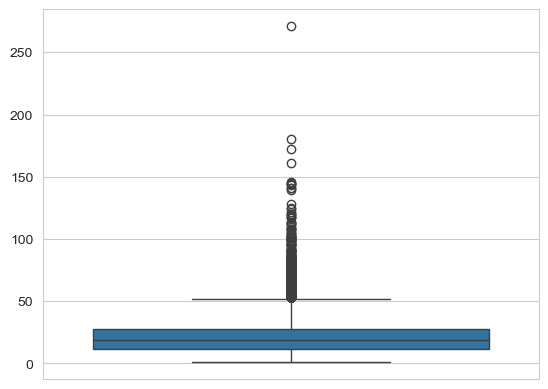

In [33]:
sns.boxplot(lengths)
plt.show()

In [34]:
# Pad each sequence to MAX_SEQ_LENGTH using KERAS' pad_sequences() function.
# Sentences longer than MAX_SEQ_LENGTH are truncated.
# Sentences shorter than MAX_SEQ_LENGTH are padded with zeroes.

# Truncation and padding can either be 'pre' or 'post'.
# For padding we are using 'pre' padding type, that is, add zeroes on the left side.
# For truncation, we are using 'post', that is, truncate a sentence from right side.

MAX_SEQ_LENGTH = 100  # sequences greater than 100 in length will be truncated

X_padded = pad_sequences(
    X_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post"
)
Y_padded = pad_sequences(
    Y_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post"
)

In [35]:
# print the first sequence
print(X_padded[0], "\n" * 3)
print(Y_padded[0])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0  6423 24231
     2  7652   102   170     2    47  1898     1   269    17     7 13230
   619  1711  2761     3] 



[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  1  1  3 11  1  6  3  2  2  5  1  4  5  6
  1  1 11  3]


#todo
RNN will learn the zero to zero mapping while training. So we don't need to worry about the padded zeroes. Please note that zero is not reserved for any word or tag, it's only reserved for padding.

In [36]:
# assign padded sequences to X and Y
X, Y = X_padded, Y_padded

## Word embeddings

Currently, each word and each tag is encoded as an integer. 

We'll use a more sophisticated technique to represent the input words (X) using what's known as **word embeddings**.

However, to represent each tag in Y, we'll simply use **one-hot encoding** scheme since there are only 13 tags in the dataset and the LSTM will have no problems in learning its own representation of these tags.

To use word embeddings, you can go for either of the following models:
1. word2vec model: https://code.google.com/archive/p/word2vec/
2. GloVe model : https://nlp.stanford.edu/projects/glove/

We're using the word2vec model for no particular reason. Both of these are very efficient in representing words. You can try both and see which one works better.

Dimensions of a word embedding is: (VOCABULARY_SIZE, EMBEDDING_DIMENSION)

### Use word embeddings for input sequences (X)

In [37]:
# word2vec download link (Size ~ 1.5GB): https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit

path = "./GoogleNews-vectors-negative300.bin"

# load word2vec using the following function present in the gensim library
word2vec = KeyedVectors.load_word2vec_format(path, binary=True)

In [38]:
# word2vec effectiveness
word2vec.most_similar(positive=["King", "Woman"], negative=["Man"])

[('Queen', 0.4929387867450714),
 ('Tupou_V.', 0.45174285769462585),
 ('Oprah_BFF_Gayle', 0.442213237285614),
 ('Jackson', 0.4402503967285156),
 ('NECN_Alison', 0.433128297328949),
 ('Whitfield', 0.42834725975990295),
 ('Ida_Vandross', 0.42084527015686035),
 ('prosecutor_Dan_Satterberg', 0.420758992433548),
 ('martin_Luther_King', 0.42059651017189026),
 ('Coretta_King', 0.4202733635902405)]

In [39]:
# assign word vectors from word2vec model

EMBEDDING_SIZE = (
    300  # each word in word2vec model is represented using a 300 dimensional vector
)
VOCABULARY_SIZE = len(word_tokenizer.word_index) + 1

# create an empty embedding matix
embedding_weights = np.zeros((VOCABULARY_SIZE, EMBEDDING_SIZE))

# create a word to index dictionary mapping
word2id = word_tokenizer.word_index

# copy vectors from word2vec model to the words present in corpus
for word, index in word2id.items():
    try:
        embedding_weights[index, :] = word2vec[word]
    except KeyError:
        pass

In [40]:
# check embedding dimension
print("Embeddings shape: {}".format(embedding_weights.shape))

Embeddings shape: (59449, 300)


In [41]:
# let's look at an embedding of a word
embedding_weights[word_tokenizer.word_index["joy"]]

array([ 0.4453125 , -0.20019531,  0.20019531, -0.03149414,  0.078125  ,
       -0.390625  ,  0.13671875, -0.13867188,  0.05395508,  0.10546875,
       -0.05029297, -0.23730469,  0.19921875,  0.12597656, -0.12695312,
        0.34179688,  0.06347656,  0.26757812, -0.07324219, -0.29101562,
        0.10498047,  0.11914062,  0.23730469,  0.00640869,  0.12451172,
       -0.00939941, -0.02770996,  0.03076172,  0.07421875, -0.22851562,
       -0.08056641, -0.05273438,  0.16894531,  0.19824219, -0.15625   ,
       -0.08740234,  0.10742188, -0.07177734,  0.05200195,  0.25976562,
        0.171875  , -0.13574219,  0.06738281,  0.00531006,  0.15527344,
       -0.03515625,  0.08789062,  0.3359375 , -0.12890625,  0.17578125,
       -0.08642578,  0.32421875, -0.09033203,  0.35351562,  0.24316406,
       -0.07470703, -0.06640625, -0.17578125,  0.06689453, -0.03833008,
        0.0100708 , -0.21484375, -0.03686523,  0.04394531,  0.02209473,
        0.00219727, -0.22460938,  0.03015137, -0.21582031,  0.16

### Use one-hot encoding for output sequences (Y)

In [42]:
# use Keras' to_categorical function to one-hot encode Y
Y = to_categorical(Y)

In [43]:
# print Y of the first output sequqnce
print(Y.shape)

(72202, 100, 13)


## Split data in training, validation and tesing sets

In [44]:
# split entire data into training and testing sets
TEST_SIZE = 0.15
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=4
)

In [45]:
# split training data into training and validation sets
VALID_SIZE = 0.15
X_train, X_validation, Y_train, Y_validation = train_test_split(
    X_train, Y_train, test_size=VALID_SIZE, random_state=4
)

In [46]:
# print number of samples in each set
print("TRAINING DATA")
print("Shape of input sequences: {}".format(X_train.shape))
print("Shape of output sequences: {}".format(Y_train.shape))
print("-" * 50)
print("VALIDATION DATA")
print("Shape of input sequences: {}".format(X_validation.shape))
print("Shape of output sequences: {}".format(Y_validation.shape))
print("-" * 50)
print("TESTING DATA")
print("Shape of input sequences: {}".format(X_test.shape))
print("Shape of output sequences: {}".format(Y_test.shape))

TRAINING DATA
Shape of input sequences: (52165, 100)
Shape of output sequences: (52165, 100, 13)
--------------------------------------------------
VALIDATION DATA
Shape of input sequences: (9206, 100)
Shape of output sequences: (9206, 100, 13)
--------------------------------------------------
TESTING DATA
Shape of input sequences: (10831, 100)
Shape of output sequences: (10831, 100, 13)


Before using RNN, we must make sure the dimensions of the data are what an RNN expects. In general, an RNN expects the following shape

Shape of X:
(#samples, #timesteps, #features)

Shape of Y:
(#samples, #timesteps, #features)

![RNN tensor shape](./jupyter resources/rnn_tensor.png)

Now, there can be various variations in the shape that you use to feed an RNN depending on the type of architecture. Since the problem we're working on has a many-to-many architecture, the input and the output both include number of timesteps which is nothing but the sequence length. But notice that the tensor X doesn't have the third dimension, that is, number of features. That's because we're going to use word embeddings before feeding in the data to an RNN, and hence there is no need to explicitly mention the third dimension. That's because when you use the Embedding() layer in Keras, you the training data will automatically be converted to (#samples, #timesteps, #features) where #features will be the embedding dimention (and note that the Embedding layer is always the very first layer of an RNN). While using the embedding layer we only need to reshape the data to (#samples, #timesteps) which is what we have done. However, note that you'll need to shape it to (#samples, #timesteps, #features) in case you don't use the Embedding() layer in Keras.

# 2. Vanilla RNN

### Uninitialised fixed embeddings
First let's try running a vanilla RNN. For this RNN we won't use the pre-trained word embeddings. We'll use randomly inititalised embeddings. Moreover, we won't update the embeddings weights.

In [47]:
# total number of tags
NUM_CLASSES = Y.shape[2]

In [48]:
# create architecture

rnn_model = Sequential()

# create embedding layer - usually the first layer in text problems
rnn_model.add(
    Embedding(
        input_dim=VOCABULARY_SIZE,  # vocabulary size - number of unique words in data
        output_dim=EMBEDDING_SIZE,  # length of vector with which each word is represented
        input_length=MAX_SEQ_LENGTH,  # length of input sequence
        trainable=False,  # False - don't update the embeddings
    )
)

# add an RNN layer which contains 64 RNN cells
rnn_model.add(
    SimpleRNN(
        64,
        return_sequences=True,  # True - return whole sequence; False - return single output of the end of the sequence
    )
)

# add time distributed (output at each sequence) layer
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation="softmax")))

## Compile model

In [49]:
rnn_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [50]:
# check summary of the model
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Fit model

In [51]:
rnn_training = rnn_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_validation, Y_validation),
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - acc: 0.8487 - loss: 0.5215 - val_acc: 0.8939 - val_loss: 0.3543
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - acc: 0.9110 - loss: 0.2954 - val_acc: 0.9254 - val_loss: 0.2483
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - acc: 0.9313 - loss: 0.2247 - val_acc: 0.9366 - val_loss: 0.2021
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - acc: 0.9395 - loss: 0.1899 - val_acc: 0.9434 - val_loss: 0.1764
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - acc: 0.9457 - loss: 0.1687 - val_acc: 0.9487 - val_loss: 0.1593
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - acc: 0.9498 - loss: 0.1546 - val_acc: 0.9518 - val_loss: 0.1481
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - acc: 0.9527 - loss: 0.1448 - val_acc: 0.9538 - val_loss: 0.1400
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - acc: 0.9546 - loss: 0.1377 - val_acc: 0.9557 - val_loss: 0.1338
Epoch 9/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 

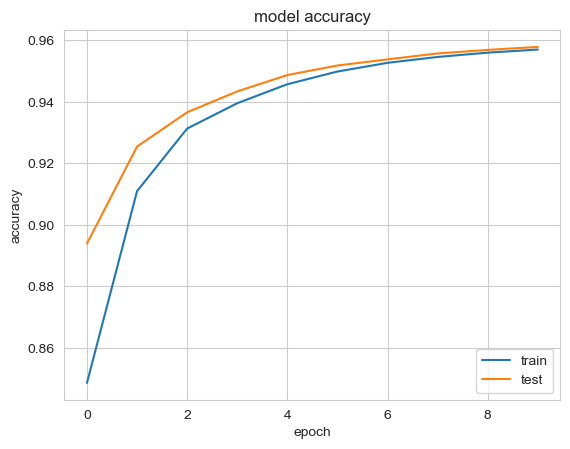

In [52]:
# visualise training history
plt.plot(rnn_training.history["acc"])
plt.plot(rnn_training.history["val_acc"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="lower right")
plt.show()

### Uninitialised trainable embeddings

In [53]:
# create architecture

rnn_model = Sequential()

# create embedding layer - usually the first layer in text problems
rnn_model.add(
    Embedding(
        input_dim=VOCABULARY_SIZE,  # vocabulary size - number of unique words in data
        output_dim=EMBEDDING_SIZE,  # length of vector with which each word is represented
        input_length=MAX_SEQ_LENGTH,  # length of input sequence
        trainable=True,  # True - update the embeddings while training
    )
)

# add an RNN layer which contains 64 RNN cells
rnn_model.add(
    SimpleRNN(
        64,
        return_sequences=True,  # True - return whole sequence; False - return single output of the end of the sequence
    )
)

# add time distributed (output at each sequence) layer
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation="softmax")))

## Compile model

In [54]:
rnn_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [55]:
# check summary of the model
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Fit model

In [56]:
rnn_training = rnn_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_validation, Y_validation),
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 61s 140ms/step - acc: 0.9644 - loss: 0.1433 - val_acc: 0.9876 - val_loss: 0.0406
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 114s 281ms/step - acc: 0.9903 - loss: 0.0299 - val_acc: 0.9901 - val_loss: 0.0289
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 84s 205ms/step - acc: 0.9928 - loss: 0.0208 - val_acc: 0.9906 - val_loss: 0.0266
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 66s 162ms/step - acc: 0.9940 - loss: 0.0171 - val_acc: 0.9908 - val_loss: 0.0263
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 65s 159ms/step - acc: 0.9948 - loss: 0.0147 - val_acc: 0.9906 - val_loss: 0.0269
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 61s 149ms/step - acc: 0.9956 - loss: 0.0127 - val_acc: 0.9905 - val_loss: 0.0278
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 61s 150ms/step - acc: 0.9963 - loss: 0.0108 - val_acc: 0.9903 - val_loss: 0.0293
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 62s 151ms/step - acc: 0.9969 - loss: 0.0092 - val_acc: 0.9901 - val_loss: 0.0312
Epoch 9/10
408/408 ━━━━━━━━━━━━

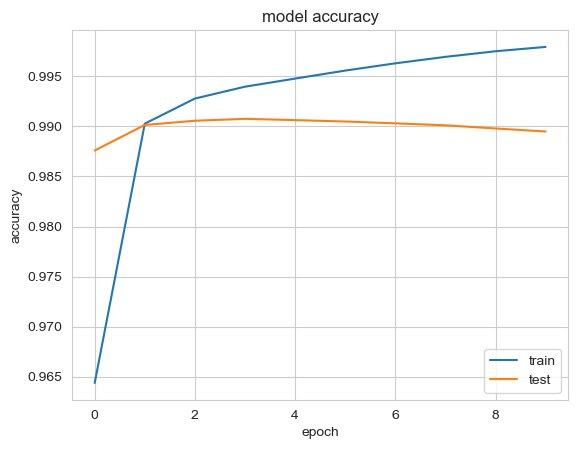

In [57]:
# visualise training history
plt.plot(rnn_training.history["acc"])
plt.plot(rnn_training.history["val_acc"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="lower right")
plt.show()

### Using pre-trained embedding weights

In [58]:
# create architecture

rnn_model = Sequential()

# create embedding layer - usually the first layer in text problems
rnn_model.add(
    Embedding(
        input_dim=VOCABULARY_SIZE,  # vocabulary size - number of unique words in data
        output_dim=EMBEDDING_SIZE,  # length of vector with which each word is represented
        input_length=MAX_SEQ_LENGTH,  # length of input sequence
        weights=[embedding_weights],  # word embedding matrix
        trainable=True,  # True - update the embeddings while training
    )
)

# add an RNN layer which contains 64 RNN cells
rnn_model.add(
    SimpleRNN(
        64,
        return_sequences=True,  # True - return whole sequence; False - return single output of the end of the sequence
    )
)

# add time distributed (output at each sequence) layer
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation="softmax")))

## Compile model

In [59]:
rnn_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [60]:
# check summary of the model
rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,834,700 (68.03 MB)

 Trainable params: 17,834,700 (68.03 MB)

 Non-trainable params: 0 (0.00 B)

## Fit model

In [61]:
rnn_training = rnn_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_validation, Y_validation),
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 68s 151ms/step - acc: 0.9729 - loss: 0.1127 - val_acc: 0.9893 - val_loss: 0.0330
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 61s 150ms/step - acc: 0.9912 - loss: 0.0260 - val_acc: 0.9907 - val_loss: 0.0261
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 65s 158ms/step - acc: 0.9930 - loss: 0.0197 - val_acc: 0.9911 - val_loss: 0.0246
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 69s 169ms/step - acc: 0.9940 - loss: 0.0167 - val_acc: 0.9913 - val_loss: 0.0242
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 68s 166ms/step - acc: 0.9948 - loss: 0.0145 - val_acc: 0.9913 - val_loss: 0.0245
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 66s 161ms/step - acc: 0.9956 - loss: 0.0126 - val_acc: 0.9912 - val_loss: 0.0253
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 72s 177ms/step - acc: 0.9963 - loss: 0.0108 - val_acc: 0.9911 - val_loss: 0.0263
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 69s 169ms/step - acc: 0.9969 - loss: 0.0092 - val_acc: 0.9908 - val_loss: 0.0285
Epoch 9/10
408/408 ━━━━━━━━━━━━━

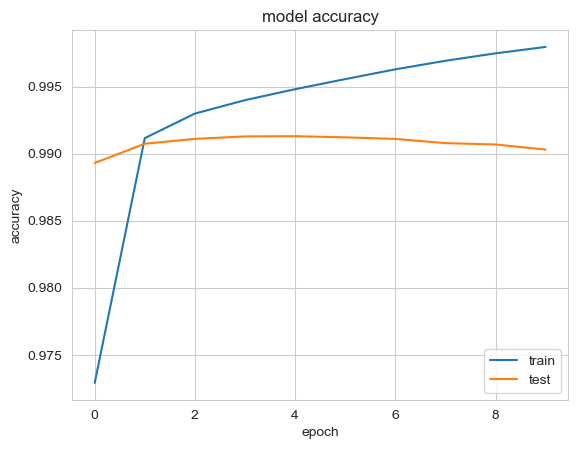

In [62]:
# visualise training history
plt.plot(rnn_training.history["acc"])
plt.plot(rnn_training.history["val_acc"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="lower right")
plt.show()

# 2. LSTM

We'll use pre-trained word embeddings in following models and allow them to be updated as well. 

## Create model architecture

In [63]:
# create architecture

lstm_model = Sequential()
lstm_model.add(
    Embedding(
        input_dim=VOCABULARY_SIZE,  # vocabulary size - number of unique words in data
        output_dim=EMBEDDING_SIZE,  # length of vector with which each word is represented
        input_length=MAX_SEQ_LENGTH,  # length of input sequence
        weights=[embedding_weights],  # word embedding matrix
        trainable=True,  # True - update embeddings_weight matrix
    )
)
lstm_model.add(LSTM(64, return_sequences=True))
lstm_model.add(TimeDistributed(Dense(NUM_CLASSES, activation="softmax")))

## Compile model

In [64]:
lstm_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [65]:
# check summary of the model
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,834,700 (68.03 MB)

 Trainable params: 17,834,700 (68.03 MB)

 Non-trainable params: 0 (0.00 B)

## Fit model

In [66]:
lstm_training = lstm_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_validation, Y_validation),
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 133s 296ms/step - acc: 0.9584 - loss: 0.1554 - val_acc: 0.9887 - val_loss: 0.0360
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 117s 286ms/step - acc: 0.9905 - loss: 0.0281 - val_acc: 0.9907 - val_loss: 0.0265
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 114s 280ms/step - acc: 0.9926 - loss: 0.0208 - val_acc: 0.9914 - val_loss: 0.0243
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 113s 278ms/step - acc: 0.9936 - loss: 0.0177 - val_acc: 0.9916 - val_loss: 0.0232
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 114s 280ms/step - acc: 0.9944 - loss: 0.0154 - val_acc: 0.9918 - val_loss: 0.0227
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 115s 282ms/step - acc: 0.9951 - loss: 0.0136 - val_acc: 0.9919 - val_loss: 0.0227
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 115s 282ms/step - acc: 0.9957 - loss: 0.0121 - val_acc: 0.9919 - val_loss: 0.0233
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 115s 282ms/step - acc: 0.9962 - loss: 0.0107 - val_acc: 0.9917 - val_loss: 0.0243
Epoch 9/10
408/408 ━━━━━

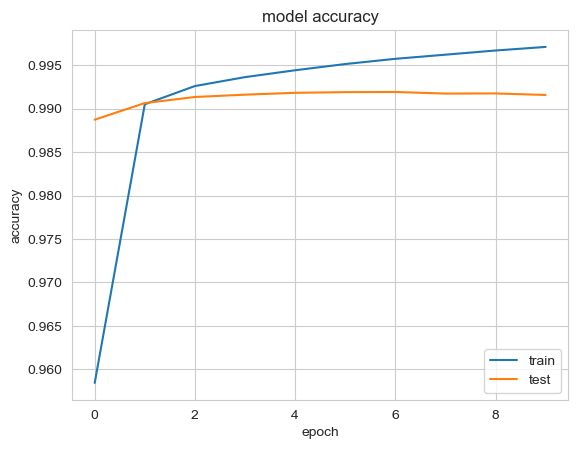

In [67]:
# visualise training history
plt.plot(lstm_training.history["acc"])
plt.plot(lstm_training.history["val_acc"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="lower right")
plt.show()

# 2. GRU

## Create model architecture

In [68]:
# create architecture

gru_model = Sequential()
gru_model.add(
    Embedding(
        input_dim=VOCABULARY_SIZE,
        output_dim=EMBEDDING_SIZE,
        input_length=MAX_SEQ_LENGTH,
        weights=[embedding_weights],
        trainable=True,
    )
)
gru_model.add(GRU(64, return_sequences=True))
gru_model.add(TimeDistributed(Dense(NUM_CLASSES, activation="softmax")))

## Compile model

In [69]:
gru_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["acc"])

In [70]:
# check summary of model
gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,834,700 (68.03 MB)

 Trainable params: 17,834,700 (68.03 MB)

 Non-trainable params: 0 (0.00 B)

## Fit model

In [71]:
gru_training = gru_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_validation, Y_validation),
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 114s 265ms/step - acc: 0.9731 - loss: 0.1022 - val_acc: 0.9896 - val_loss: 0.0294
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 103s 253ms/step - acc: 0.9914 - loss: 0.0239 - val_acc: 0.9910 - val_loss: 0.0244
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 105s 257ms/step - acc: 0.9930 - loss: 0.0189 - val_acc: 0.9914 - val_loss: 0.0231
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 113s 276ms/step - acc: 0.9938 - loss: 0.0166 - val_acc: 0.9916 - val_loss: 0.0228
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 112s 274ms/step - acc: 0.9944 - loss: 0.0150 - val_acc: 0.9918 - val_loss: 0.0227
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 112s 274ms/step - acc: 0.9949 - loss: 0.0136 - val_acc: 0.9919 - val_loss: 0.0231
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 116s 285ms/step - acc: 0.9954 - loss: 0.0123 - val_acc: 0.9918 - val_loss: 0.0238
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 106s 260ms/step - acc: 0.9959 - loss: 0.0111 - val_acc: 0.9918 - val_loss: 0.0245
Epoch 9/10
408/408 ━━━━━

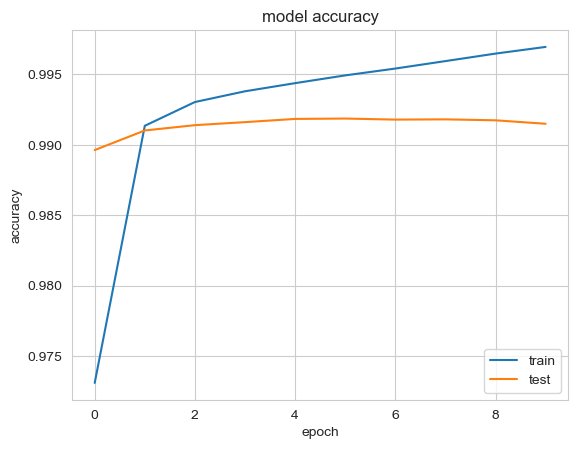

In [72]:
# visualise training history
plt.plot(gru_training.history["acc"])
plt.plot(gru_training.history["val_acc"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="lower right")
plt.show()

# 3. Bidirectional LSTM

## Create model architecture

In [73]:
# create architecture

bidirect_model = Sequential()
bidirect_model.add(
    Embedding(
        input_dim=VOCABULARY_SIZE,
        output_dim=EMBEDDING_SIZE,
        input_length=MAX_SEQ_LENGTH,
        weights=[embedding_weights],
        trainable=True,
    )
)
bidirect_model.add(Bidirectional(LSTM(64, return_sequences=True)))
bidirect_model.add(TimeDistributed(Dense(NUM_CLASSES, activation="softmax")))

## Compile model

In [74]:
bidirect_model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["acc"]
)

In [75]:
# check summary of model
bidirect_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,834,700 (68.03 MB)

 Trainable params: 17,834,700 (68.03 MB)

 Non-trainable params: 0 (0.00 B)

## Fit model

In [76]:
bidirect_training = bidirect_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_validation, Y_validation),
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 171s 402ms/step - acc: 0.9650 - loss: 0.1204 - val_acc: 0.9917 - val_loss: 0.0252
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 153s 375ms/step - acc: 0.9937 - loss: 0.0194 - val_acc: 0.9935 - val_loss: 0.0192
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 151s 370ms/step - acc: 0.9955 - loss: 0.0136 - val_acc: 0.9941 - val_loss: 0.0174
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 147s 360ms/step - acc: 0.9965 - loss: 0.0107 - val_acc: 0.9944 - val_loss: 0.0168
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 146s 358ms/step - acc: 0.9973 - loss: 0.0084 - val_acc: 0.9945 - val_loss: 0.0166
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 119s 292ms/step - acc: 0.9980 - loss: 0.0065 - val_acc: 0.9946 - val_loss: 0.0170
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 201s 494ms/step - acc: 0.9985 - loss: 0.0050 - val_acc: 0.9945 - val_loss: 0.0180
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 155s 379ms/step - acc: 0.9989 - loss: 0.0037 - val_acc: 0.9943 - val_loss: 0.0195
Epoch 9/10
408/408 ━━━━━

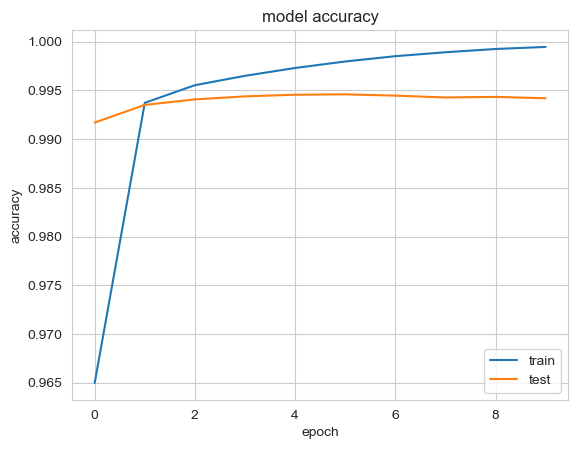

In [77]:
# visualise training history
plt.plot(bidirect_training.history["acc"])
plt.plot(bidirect_training.history["val_acc"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="lower right")
plt.show()

# 5. Model evaluation

In [78]:
loss, accuracy = rnn_model.evaluate(X_test, Y_test, verbose=1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.9904 - loss: 0.0326
Loss: 0.032563626766204834,
Accuracy: 0.9903592467308044


In [79]:
loss, accuracy = lstm_model.evaluate(X_test, Y_test, verbose=1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - acc: 0.9916 - loss: 0.0264
Loss: 0.026363981887698174,
Accuracy: 0.991627037525177


In [80]:
loss, accuracy = gru_model.evaluate(X_test, Y_test, verbose=1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - acc: 0.9917 - loss: 0.0263
Loss: 0.02632034756243229,
Accuracy: 0.9917101860046387


In [81]:
loss, accuracy = bidirect_model.evaluate(X_test, Y_test, verbose=1)
print("Loss: {0},\nAccuracy: {1}".format(loss, accuracy))

339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - acc: 0.9942 - loss: 0.0222
Loss: 0.02220718376338482,
Accuracy: 0.9942110180854797
